# Linear and logistic regression assignment

## Business Understanding

House prices are influenced by various factors. Understanding these factors and their impact on the unit price of a house is crucial for both the buyers and the sellers in the real estate market, as choosing the right price can bring significant financial benefits to both parties. Finding the right price for a house may be challenging, as it requires a lot of information about the various influencing factors.

The objective of this assignment was to create linear and logistic regression models to predict the unit price of a house based on various features of the house and its location. The linear model is used to predict the actual unit price of the house, while the logistic model is used to classify whether the unit price is above or below the average unit price in the dataset.

Various metrics are used to evaluate the performance of both models, including mean absolute error and R^2 score for the linear regression model, and accuracy, classification report, and confusion matrix for the logistic regression model. The importance of each feature in the logistic regression model is also evaluated using permutation importance.

## Data Understanding

The dataset used in this assignment is the "Real estate valuation data set" from the UCI Machine Learning Repository. The dataset contains 414 datapoints, each representing a house located in Taipei, Taiwan. Each datapoint has 7 features, including the unit price of the house. Below you can find the variables in the dataset:

- No: Unique identifier for each house
- X1: The transaction date
- X2: The house age (in years)
- X3: The distance to the nearest MRT station (in meters)
- X4: The number of convenience stores within walking distance
- X5: The latitude of the house location
- X6: The longitude of the house location
- Y: The unit price of the house (in New Taiwan Dollars per ping, where 1 ping = 3.3 square meters)


In [360]:
from sklearn.metrics import mean_absolute_error
from ucimlrepo import fetch_ucirepo

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

df = real_estate_valuation.data.original

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


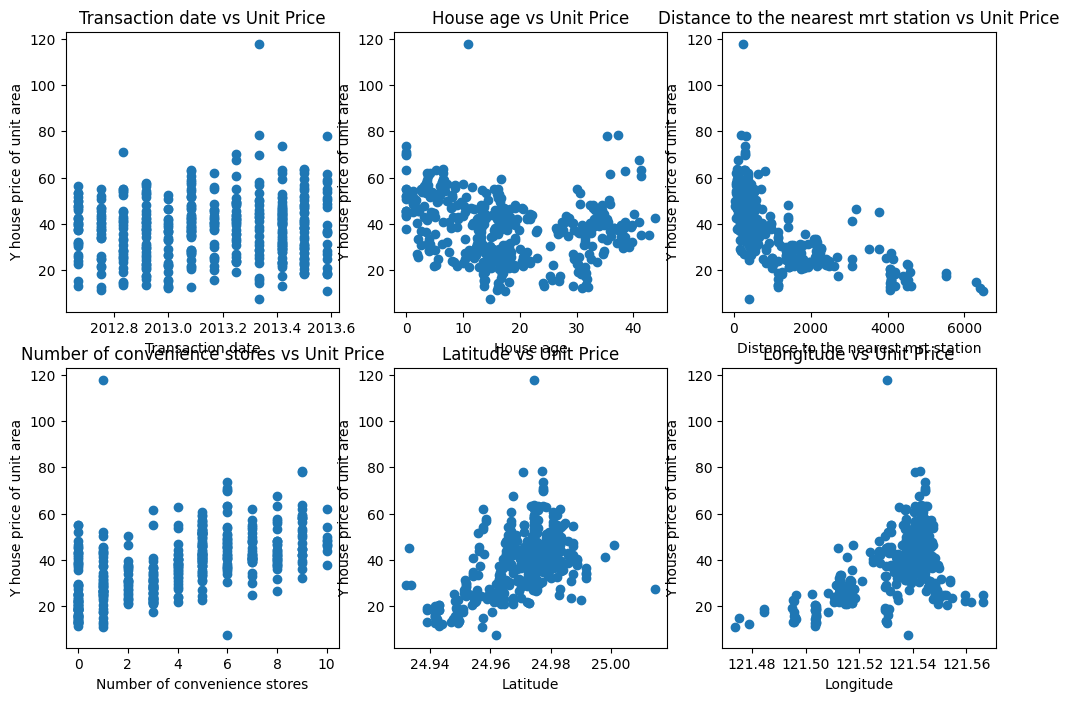

In [361]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, col in enumerate(df.columns.values[1:-1]):
    plt.subplot(2, 3, i + 1)
    plt.scatter(df[col], df['Y house price of unit area'])
    plt.xlabel(col[3:].capitalize())
    plt.ylabel('Y house price of unit area')
    plt.title(f'{col[3:].capitalize()} vs Unit Price')


Above is a scatter plot of each feature against the unit price of the house to visualize their relationships. It can be used to identify potential correlations between the feature and the unit price before even building the models.

## Data Preparation

According to the UCI Machine Learning Repository, the dataset is already clean and does not contain any missing values. Though, the ID column is dropped as it does not provide any useful data for the regression analysis.

The target variable is then separated from the features, and the dataset is split into training and testing sets. In this case, 30% of the data is used for testing. Though not strictly necessary for regression models, the features are then scaled using a standard scaler. This is done to improve the performance of the model.

Finally, for the logistic regression model, the target variable is converted into a binary variable based on whether the unit price is above or below the average unit price in the dataset.

In [362]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.drop(columns=['No'])
X = df.drop(columns=['Y house price of unit area'])
y = df['Y house price of unit area']

X_train, X_test, y_train_linear, y_test_linear = train_test_split(X, y, test_size=0.3, random_state=123)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

average_unit_price = df["Y house price of unit area"].mean()
y_train_logistic = y_train_linear.apply(lambda x: 1 if x > average_unit_price else 0)
y_test_logistic = y_test_linear.apply(lambda x: 1 if x > average_unit_price else 0)

print(f"Average unit price: {average_unit_price:.2f}")

Average unit price: 37.98


## Modeling

Both the linear and logistic regression models are built using the same training features data.

The linear regression model is used to predict the actual unit price of the house and so is trained using the continuous target variable.

In contrast, the logistic regression model is used to classify whether the unit price is above or below the average unit price and so is trained using the binary target variable.

### Linear regression

First we clean up the feature names for better readability in the output.

In [363]:
clean_X_columns = [col[3:].capitalize() for col in X.columns]

Linear regression model is then trained using LinearRegression class from sklearn library.

In [364]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train_linear)

print("Linear regression coefficients:")
for name, coef in zip(clean_X_columns, lin_model.coef_):
    print(f"\t{name.capitalize()}: {coef:.4f}")

print(f"\nIntercept: {lin_model.intercept_:.4f}")


Linear regression coefficients:
	Transaction date: 1.5032
	House age: -3.0049
	Distance to the nearest mrt station: -6.0670
	Number of convenience stores: 3.1549
	Latitude: 2.7356
	Longitude: -0.4031

Intercept: 38.2035


The coefficients of the linear regression model are then visualized using a bar plot.

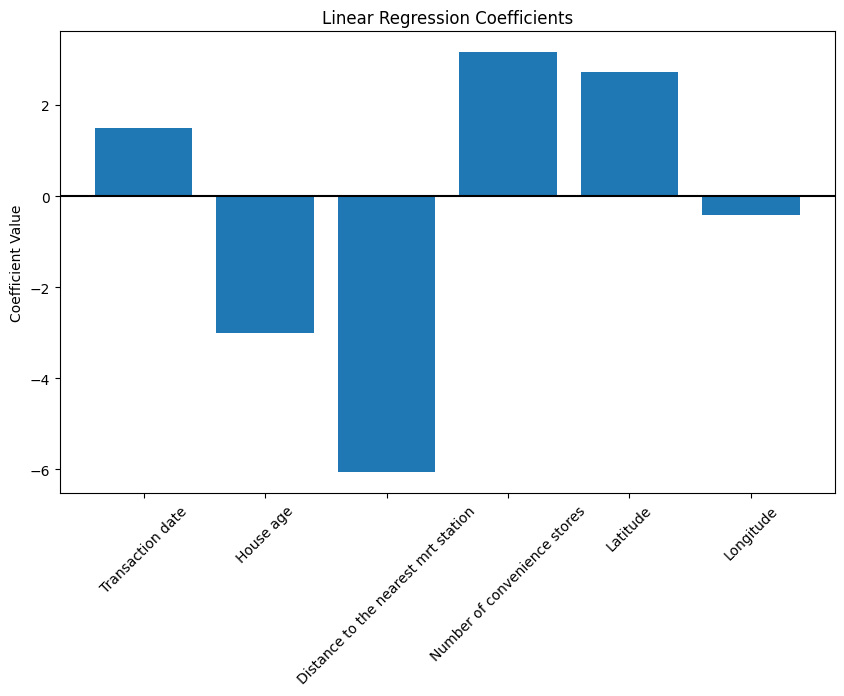

In [365]:
plt.figure(figsize=(10, 6))
plt.bar(clean_X_columns, lin_model.coef_)
plt.ylabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.axhline(y=0, color='black', linestyle='-')
plt.xticks(rotation=45)
plt.show()

The coefficients indicate the change in the unit price of the house for a one-unit increase in the corresponding feature, while holding all other features constant.

Positive coefficients indicate that an increase in the feature leads to an increase in the unit price, while negative coefficients indicate the opposite. The magnitude of the coefficients indicates the strength of the relationship between the feature and the unit price. Coefficients near zero indicate a weak or non-existent relationship.

As can be seen from the printed coefficients and the bar plot, the distance to the nearest MRT station (X3) has the most significant negative impact on the unit price, while the number of convenience stores within walking distance (X4) has the most significant positive impact.

### Logistic regression

As with the linear regression model, the logistic regression model is trained using the sklearn library, specifically the LogisticRegression class.

In [366]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train_logistic)

print("Logistical regression coefficients:")
for name, coef in zip(clean_X_columns, log_model.coef_[0]):
    print(f"\t{name.capitalize()}: {coef:.4f}")

print(f"\nIntercept: {log_model.intercept_[0]:.4f}")


Logistical regression coefficients:
	Transaction date: 0.3602
	House age: -0.7147
	Distance to the nearest mrt station: -2.3555
	Number of convenience stores: 0.6579
	Latitude: 1.1064
	Longitude: 0.2827

Intercept: -0.6985


Like with the linear regression model, the coefficients of the logistic regression model are visualized using a bar plot.

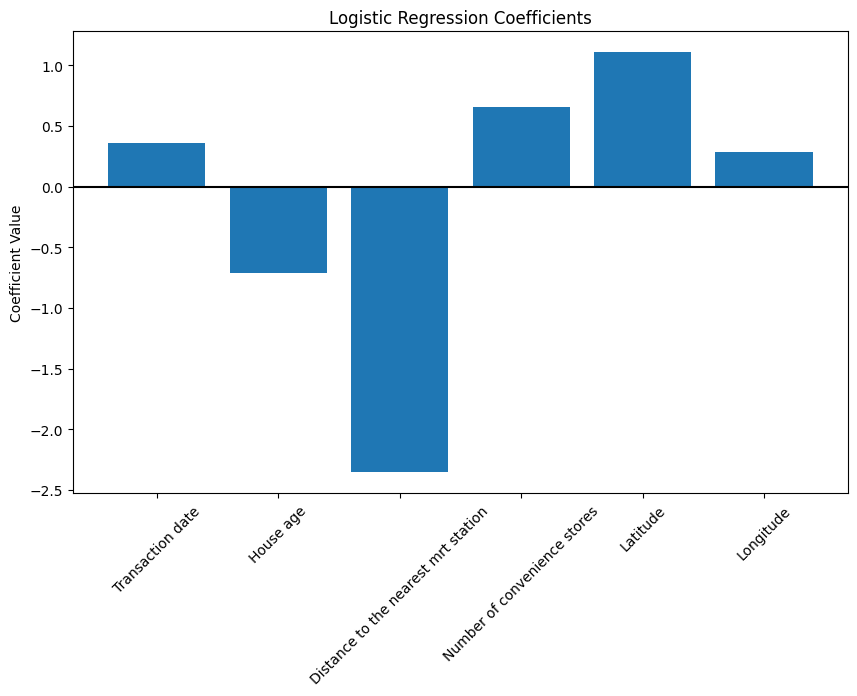

In [367]:
plt.figure(figsize=(10, 6))
plt.bar(clean_X_columns, log_model.coef_[0])
plt.ylabel('Coefficient Value')
plt.title('Logistic Regression Coefficients')
plt.axhline(y=0, color='black', linestyle='-')
plt.xticks(rotation=45)
plt.show()

The barchart for the logistic regression coefficients resembles that of the linear regression model, indicating that the same features have a significant impact on the unit price of the house.

This is expected, as both models are based on the same underlying relationships between the features and the unit price. Though this time, latitude is now the feature with the most significant positive impact on whether the unit price is above average, while the distance to the nearest MRT station remains the feature with the most significant negative impact.

#### Feature importance


The importance of each feature in the logistic regression model is evaluated using permutation importance. This method involves randomly shuffling the values of each feature and measuring the decrease in model performance. Features that lead to a significant decrease in performance when shuffled are considered more important.

The permutation importance results are visualized using a box plot.

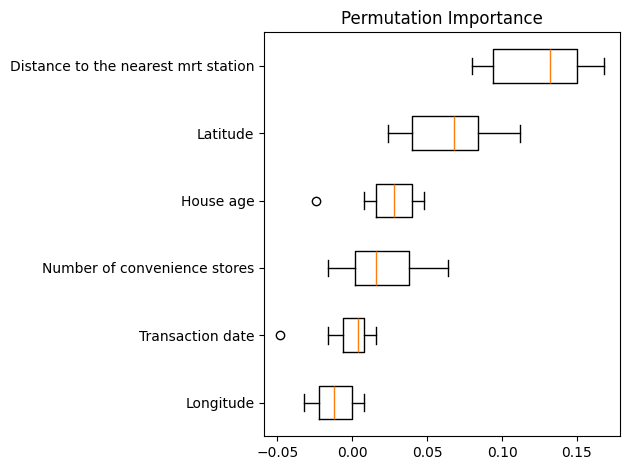

In [368]:
import numpy as np
from sklearn.inspection import permutation_importance

result = permutation_importance(log_model, X_test_scaled, y_test_logistic, n_repeats=10, scoring="accuracy", random_state=123, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
sorted_importances = result.importances[sorted_idx]
ax.boxplot(sorted_importances.T, vert=False)
n_features = sorted_importances.shape[0]
ax.set_yticks(np.arange(1, n_features + 1))
ax.set_yticklabels(np.array(clean_X_columns)[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

## Evaluation

Both models are evaluated using the testing dataset that was set aside during the data preparation phase.

The linear regression model is evaluated using mean absolute error and R^2 score, while the logistic regression model is evaluated using accuracy, classification report, and confusion matrix.

### Linear regression

First, the predictions of the linear regression model are obtained using the testing dataset. The residuals, which are the differences between the actual and predicted unit prices, are then calculated and visualized using a scatter plot.

The mean absolute error and R^2 score are also calculated and printed, along with the mean and standard deviation of the residuals.

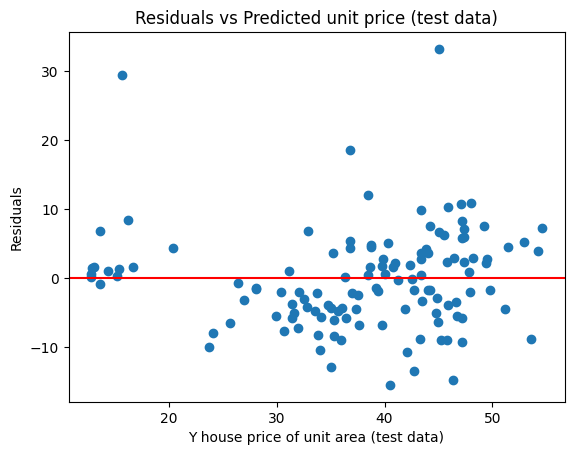

Test data - Mean Absolute Error: 5.35
Test data - R^2 score: 0.67
Test data - Residual mean: -0.26
Test data - Residual standard deviation: 7.26


In [369]:
y_lin_predict = lin_model.predict(X_test_scaled)
residuals_test = y_test_linear - y_lin_predict

plt.scatter(y_lin_predict, residuals_test)
plt.xlabel("Y house price of unit area (test data)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted unit price (test data)")
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

print(f"Test data - Mean Absolute Error: {mean_absolute_error(y_test_linear, y_lin_predict):.2f}")
print(f"Test data - R^2 score: {lin_model.score(X_test_scaled, y_test_linear):.2f}")
print(f"Test data - Residual mean: {residuals_test.mean():.2f}")
print(f"Test data - Residual standard deviation: {residuals_test.std():.2f}")

Then, the same evaluation is performed using the training dataset to check for overfitting.

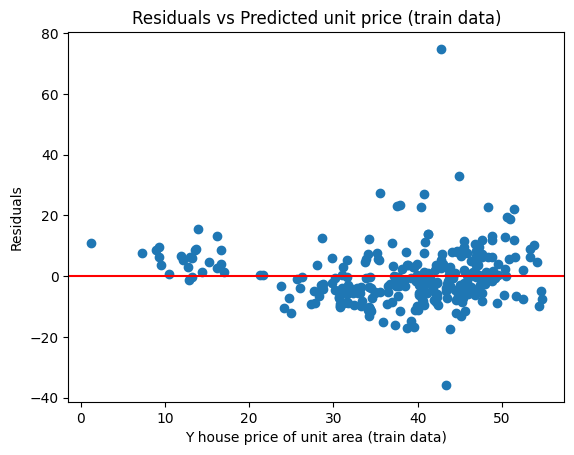

Train data - Mean Absolute Error: 6.50
Train data - R^2 score: 0.5495
Train data - Residual mean: 0.00
Train data - Residual standard deviation: 9.39


In [370]:
y_lin_predict_train = lin_model.predict(X_train_scaled)
residuals_train = y_train_linear - y_lin_predict_train

plt.scatter(y_lin_predict_train, residuals_train)
plt.xlabel("Y house price of unit area (train data)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted unit price (train data)")
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

print(f"Train data - Mean Absolute Error: {mean_absolute_error(y_train_linear, y_lin_predict_train):.2f}")
print(f"Train data - R^2 score: {lin_model.score(X_train_scaled, y_train_linear):.4f}")
print(f"Train data - Residual mean: {residuals_train.mean():.2f}")
print(f"Train data - Residual standard deviation: {residuals_train.std():.2f}")

The linear regression model shows good performance on both the training and testing datasets, with a mean absolute error of approximately 5.35 and an R^2 score of approximately 0.67 on the test data. The residuals are relatively small and centered around zero, indicating that the model is able to capture the underlying relationships between the features and the unit price of the house reasonably well. There is no clear pattern in the residuals, suggesting that the model does not suffer from significant heteroscedasticity or non-linearity issues.

The performance of the model on the training data is slightly better than on the testing data, which is expected. However, the difference in performance is not large enough to suggest significant overfitting. Overall, the linear regression model demonstrates a reasonable ability to predict the unit price of a house based on its features and location.

### Logistic regression

The predictions of the logistic regression model are first obtained using cross-validation on the training dataset. The accuracy, classification report, and confusion matrix are then calculated and visualized to evaluate the performance of the model on the training data.

Finally, the same evaluation is performed using the testing dataset to evaluate the performance of the model on unseen data.

Cross-validation accuracy: 82.7%
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       139
           1       0.80      0.88      0.84       150

    accuracy                           0.83       289
   macro avg       0.83      0.82      0.83       289
weighted avg       0.83      0.83      0.83       289



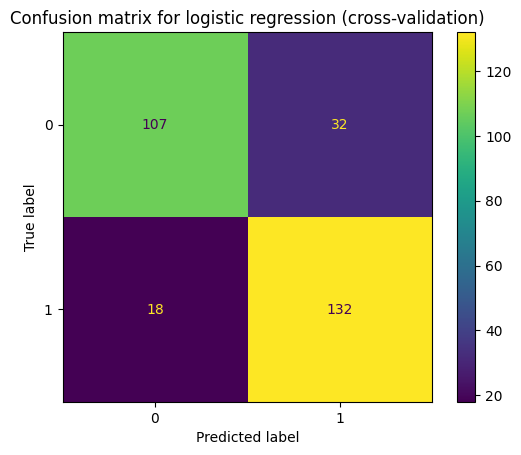

In [371]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_log_predict_cv = cross_val_predict(estimator=log_model, X=X_train_scaled, y=y_train_logistic, cv=10)

cv_accuracy = accuracy_score(y_train_logistic, y_log_predict_cv)
print(f"Cross-validation accuracy: {cv_accuracy*100:.1f}%")

report_cv = classification_report(y_train_logistic, y_log_predict_cv)
print(report_cv)

cm_cross_val = confusion_matrix(y_train_logistic, y_log_predict_cv)
cmd_cross_val = ConfusionMatrixDisplay(cm_cross_val, display_labels=log_model.classes_)
cmd_cross_val.plot()
plt.title("Confusion matrix for logistic regression (cross-validation)")
plt.show()


Test accuracy: 82.4 %
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        61
           1       0.81      0.86      0.83        64

    accuracy                           0.82       125
   macro avg       0.83      0.82      0.82       125
weighted avg       0.83      0.82      0.82       125



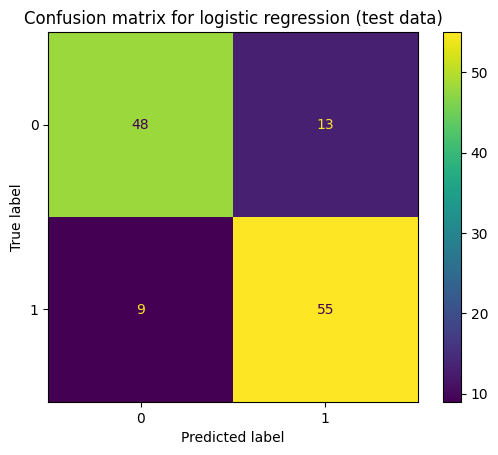

In [372]:
y_log_predict = log_model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test_logistic, y_log_predict)
print(f"Test accuracy: {test_accuracy*100:.1f} %")

report = classification_report(y_test_logistic, y_log_predict)
print(report)

cm = confusion_matrix(y_test_logistic, y_log_predict)
cmd = ConfusionMatrixDisplay(cm, display_labels=log_model.classes_)
cmd.plot()
plt.title("Confusion matrix for logistic regression (test data)")
plt.show()


The logistic regression model shows good performance on both the training and testing datasets, with an accuracy of approximately 82% on the test data. The classification report indicates that the model performs better in classifying houses with below average unit price (class 0) than those with above average unit price (class 1), as indicated by the higher precision and recall for class 0. The confusion matrix shows that the model correctly classified 103 houses and misclassified 22 houses in the test dataset. Overall, the logistic regression model demonstrates a reasonable ability to classify houses based on their unit price, though there is room for improvement, especially in classifying houses with above average unit price.

The cross-validation results on the training data show a similar pattern, with an accuracy of approximately 82% and better performance in classifying houses with below average unit price. The confusion matrix for the cross-validation also shows that the model correctly classified 242 houses and misclassified 50 houses in the training dataset. This suggests that the model is not overfitting and is able to generalize well to unseen data.

## Deployment

The linear and logistic regression models can be deployed in a real-world application to predict the unit price of a house based on its features and location. The models can be integrated into a web application or a mobile app, where users can input the relevant features of a house and receive predictions for the unit price or classification of whether the unit price is above or below average.

The models are not perfect and may not capture all the complexities of the real estate market, but they can provide valuable insights and predictions based on the available data. It is important to regularly update and retrain the models with new data to ensure their continued accuracy and relevance in a changing market.